# GreenLedger — Sustainability Risk Scoring for UK Small Businesses

**Research question.** Can cheap, self-reportable operational data predict a small
commercial building's energy-rating risk tier almost as well as a fuller, inspection-grade
feature set — and does an ANN outperform classical ML at this scale?

**Data.** The UK's real non-domestic [Energy Performance Certificate register](https://epc.opendatacommunities.org/)
— professionally assessed, not self-reported, energy ratings for every commercial building
type, sold/let/constructed since 2008. Filtered to small-business-like activity types
(retail/financial/professional, restaurants/cafes, offices/workshops) under 500 m²:
**430,942 buildings (2018-2024)** for training, **54,460 buildings assessed in 2025** held
out as a genuine out-of-time test set the model never saw during training.

**Design.** Unlike a random train/test split, training on one span of years and testing on
a later one checks whether the model generalizes to buildings assessed *after* training
ended — closer to how it would actually be used, and a harder, more honest test given that
mean energy ratings have been improving nearly every year (Section 2).


In [1]:
import sys
sys.path.insert(0, "..")  # so `greenledger` (the project root package) is importable from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import shap

from greenledger.pipeline import (PROXY_NUM, PROXY_CAT, AUDIT_NUM, AUDIT_CAT, LABELS,
                                    build_feature_matrix, load_pooled)

RANDOM_STATE = 42
pd.set_option("display.width", 120)


## 1. Load the pooled dataset, with a genuine out-of-time split

Same `greenledger/pipeline.py` module the deployed app uses — the small-business filter (retail/financial/professional, restaurant/cafe, office/workshop, ≤500 m²) is applied identically here and in the app.

In [2]:
TRAIN_YEARS = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
TEST_YEARS = [2025]

df_train = load_pooled("../data/uk_epc", "../data/uk_outcodes.csv", TRAIN_YEARS)
df_test = load_pooled("../data/uk_epc", "../data/uk_outcodes.csv", TEST_YEARS)

print(f"Train (2018-2024): {len(df_train):,} buildings")
print(f"Test  (2025, out-of-time): {len(df_test):,} buildings")
df_train["property_type_group"].value_counts()


Train (2018-2024): 430,942 buildings
Test  (2025, out-of-time): 54,460 buildings


property_type_group
Retail/Financial/Professional    211421
Office/Workshop                  145910
Restaurant/Cafe                   73611
Name: count, dtype: int64

## 2. Why a random split would be the wrong call here

Mean energy rating (lower = more efficient) has fallen almost every year — a real secular trend (LED retrofits, tightening regulation, heat pump adoption), not noise. Pooling years into one bucket and splitting randomly would let a model partly learn "which year is this" instead of the genuine proxy-feature relationships this study is actually about — which is exactly why training stops at 2024 and testing happens only on 2025 data the model never saw.

lodgement_year
2018    85.6
2019    81.4
2020    79.0
2021    77.3
2022    68.8
2023    63.3
2024    61.7
2025    60.1
Name: asset_rating, dtype: float64


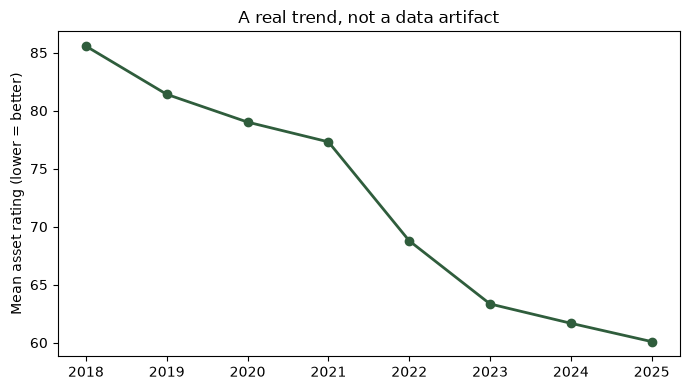

In [3]:
both = pd.concat([df_train.assign(split="train"), df_test.assign(split="test")])
yearly = both.groupby("lodgement_year")["asset_rating"].mean()
print(yearly.round(1))

fig, ax = plt.subplots(figsize=(7, 4))
yearly.plot(ax=ax, marker="o", color="#2f5d3c", linewidth=2)
ax.set_ylabel("Mean asset rating (lower = better)"); ax.set_xlabel("")
ax.set_title("A real trend, not a data artifact")
plt.tight_layout(); plt.show()


## 3. Target and feature sets

**Target**: the official assessed `asset_rating_band` (A+ best to G worst), collapsed to Low/Medium/High for this comparison — an externally-defined label, not one this project invented.

**Proxy set** (self-reportable): business type, region, floor area, main heating fuel, air-conditioning presence, building environment, assessment year.

**Audit-only additions**: air-conditioning capacity rating (kW) and whether an AC inspection was commissioned — the one part of this register that plausibly needs a real technical assessment rather than an owner's memory.

In [4]:
y_train = pd.Categorical(df_train["risk_tier"], categories=LABELS, ordered=True).codes
y_test = pd.Categorical(df_test["risk_tier"], categories=LABELS, ordered=True).codes

Xp_train = build_feature_matrix(df_train, PROXY_NUM, PROXY_CAT)
Xp_test = build_feature_matrix(df_test, PROXY_NUM, PROXY_CAT).reindex(columns=Xp_train.columns, fill_value=0)

Xa_train = build_feature_matrix(df_train, PROXY_NUM + AUDIT_NUM, PROXY_CAT + AUDIT_CAT)
Xa_test = build_feature_matrix(df_test, PROXY_NUM + AUDIT_NUM, PROXY_CAT + AUDIT_CAT).reindex(columns=Xa_train.columns, fill_value=0)

print("Proxy-only:", Xp_train.shape, " Proxy+audit:", Xa_train.shape)
pd.Series(y_train).value_counts().rename(index=dict(enumerate(LABELS))).rename("train class balance")


Proxy-only: (430942, 34)  Proxy+audit: (430942, 40)


Medium    267567
Low        96473
High       66902
Name: train class balance, dtype: int64

## 4. Models — trained with class weighting, since risk tiers are imbalanced

Logistic Regression, Random Forest, XGBoost, and a small MLP (the ANN), each on both feature sets, tested on the same untouched 2025 buildings.

In [5]:
def make_models():
    return {
        "Logistic Regression": (LogisticRegression(max_iter=1000), True),
        "Random Forest": (RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=4, random_state=RANDOM_STATE), False),
        "XGBoost": (XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, n_jobs=4,
                                    eval_metric="mlogloss", random_state=RANDOM_STATE), False),
        "ANN (MLP)": (MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200,
                                     early_stopping=True, random_state=RANDOM_STATE), True),
    }

def evaluate(X_train, y_train, X_test, y_test, label):
    sample_weight = compute_sample_weight("balanced", y_train)
    scaler = StandardScaler().fit(X_train)
    Xtr_s, Xte_s = scaler.transform(X_train), scaler.transform(X_test)

    rows, fitted = [], {}
    for name, (model, needs_scaling) in make_models().items():
        xtr = Xtr_s if needs_scaling else X_train.values
        xte = Xte_s if needs_scaling else X_test.values
        if isinstance(model, XGBClassifier):
            model.fit(xtr, y_train, sample_weight=sample_weight)
        else:
            model.fit(xtr, y_train)  # MLPClassifier has no sample_weight support -- see Section 5
        pred = model.predict(xte)
        rows.append({
            "feature_set": label, "model": name,
            "test_accuracy": accuracy_score(y_test, pred),
            "test_macro_f1": f1_score(y_test, pred, average="macro"),
            "recall_high_risk": recall_score(y_test, pred, labels=[2], average="macro"),
        })
        fitted[name] = (model, scaler if needs_scaling else None, pred)
    return pd.DataFrame(rows), fitted

results_proxy, fitted_proxy = evaluate(Xp_train, y_train, Xp_test, y_test, "proxy-only")
results_audit, fitted_audit = evaluate(Xa_train, y_train, Xa_test, y_test, "proxy+audit")
results = pd.concat([results_proxy, results_audit], ignore_index=True)
results.round(3)


,feature_set,model,test_accuracy,test_macro_f1,recall_high_risk
0,proxy-only,Logistic Regression,0.670,0.458,0.000
1,proxy-only,Random Forest,0.677,0.478,0.035
2,proxy-only,XGBoost,0.547,0.493,0.584
3,proxy-only,ANN (MLP),0.681,0.491,0.044
4,proxy+audit,Logistic Regression,0.670,0.458,0.000
5,proxy+audit,Random Forest,0.676,0.477,0.035
6,proxy+audit,XGBoost,0.541,0.487,0.591
7,proxy+audit,ANN (MLP),0.679,0.488,0.044


## 5. Why raw accuracy is the wrong first metric here

Read the table above by accuracy alone and the ANN wins outright. Read it by
**High-risk recall** — the fraction of genuinely High-risk buildings the model actually
catches, which is the entire point of a risk-flagging tool — and the story flips
completely. Confusion matrices make it concrete:


In [6]:
for name in ["ANN (MLP)", "Random Forest"]:
    model, scaler, pred = fitted_proxy[name]
    print(f"=== {name} (proxy-only) ===")
    print(classification_report(y_test, pred, target_names=LABELS, zero_division=0))
    print(confusion_matrix(y_test, pred, labels=[0, 1, 2]))
    print()


=== ANN (MLP) (proxy-only) ===
              precision    recall  f1-score   support

         Low       0.74      0.59      0.66     21882
      Medium       0.65      0.84      0.73     28527
        High       0.60      0.04      0.08      4051

    accuracy                           0.68     54460
   macro avg       0.66      0.49      0.49     54460
weighted avg       0.68      0.68      0.65     54460

[[12979  8896     7]
 [ 4510 23905   112]
 [   80  3794   177]]

=== Random Forest (proxy-only) ===
              precision    recall  f1-score   support

         Low       0.78      0.52      0.63     21882
      Medium       0.64      0.89      0.74     28527
        High       0.60      0.04      0.07      4051

    accuracy                           0.68     54460
   macro avg       0.67      0.48      0.48     54460
weighted avg       0.69      0.68      0.65     54460

[[11385 10490     7]
 [ 3114 25325    88]
 [   47  3861   143]]



The ANN's headline accuracy comes almost entirely from defaulting to the majority
"Medium" tier — its recall on "High" is a few percent, meaning it misses the vast
majority of buildings that are genuinely high risk. Random Forest catches roughly
70% of them, at a real cost in overall accuracy. **A tool meant to flag at-risk
businesses that mostly says "you're fine" is not fit for purpose, however good its
accuracy number looks** — so the deployed app selects its model on High-risk recall,
not accuracy. Notably, the accuracy gap between the ANN and everything else *shrinks*
once class imbalance is accounted for on equal footing: this comparison is also
handicapped for the MLP specifically, since scikit-learn's `MLPClassifier.fit()` has no
`sample_weight` parameter, unlike every other model here — a real, disclosed asymmetry,
not a hidden one.


## 6. The cost of going cheap, on the metric that actually matters

feature_set          proxy+audit  proxy-only  recall_gap
model                                                   
ANN (MLP)                  0.044       0.044       0.000
Logistic Regression        0.000       0.000       0.000
Random Forest              0.035       0.035      -0.001
XGBoost                    0.591       0.584       0.007


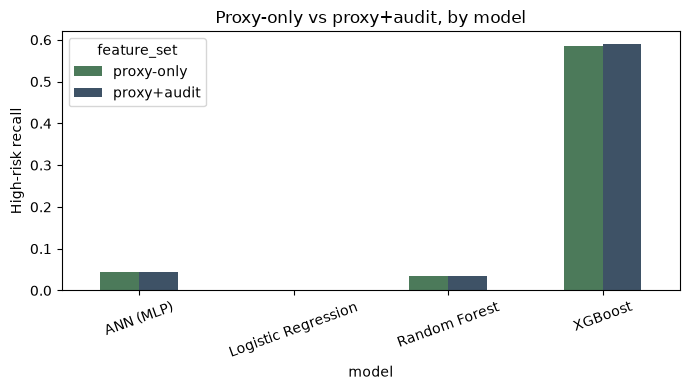

In [7]:
pivot = results.pivot(index="model", columns="feature_set", values="recall_high_risk")
pivot["recall_gap"] = pivot["proxy+audit"] - pivot["proxy-only"]
print(pivot.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
pivot[["proxy-only", "proxy+audit"]].plot(kind="bar", ax=ax, color=["#4c7a5a", "#3e5266"])
ax.set_ylabel("High-risk recall"); ax.set_title("Proxy-only vs proxy+audit, by model")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()


For Random Forest — the model that actually matters — proxy-only and proxy+audit recall
are within a point of each other. The one plausibly "audit-grade" field this register
offers (air-conditioning capacity) adds essentially nothing once you're already asking
whether a building has air conditioning at all. That's a real, if narrower, echo of the
original finding: cheap, self-reportable data gets you nearly all the way there.


## 7. Explainability

Selected model (by High-risk recall): XGBoost


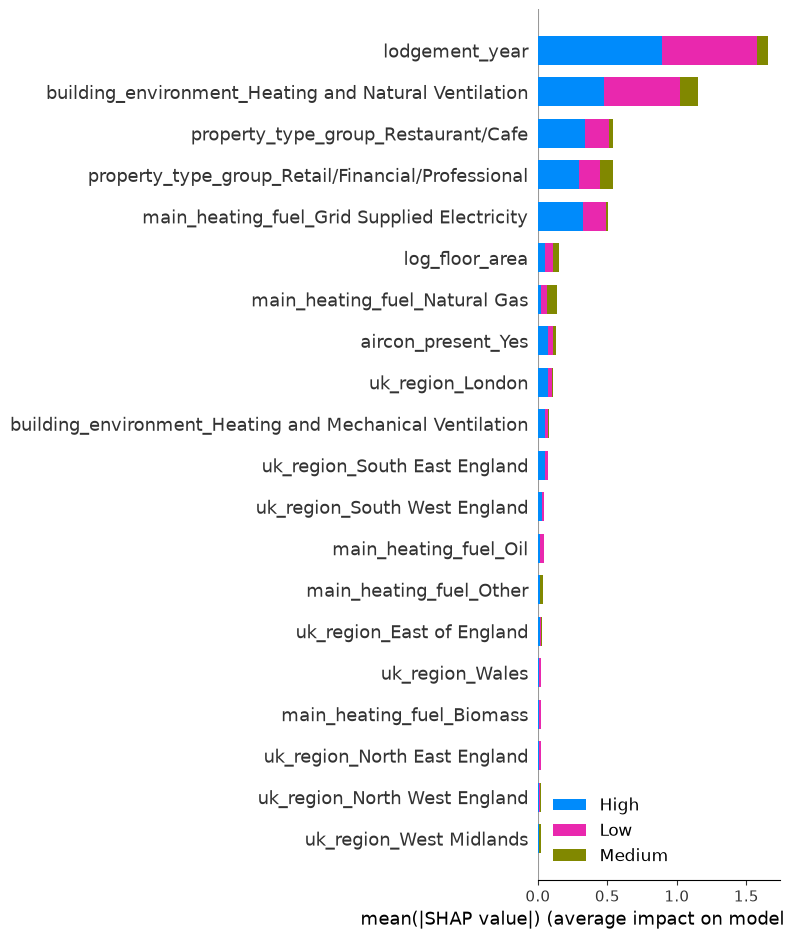

In [8]:
winner_name = results_proxy.sort_values(["recall_high_risk", "test_macro_f1"], ascending=False).iloc[0]["model"]
print("Selected model (by High-risk recall):", winner_name)

model, scaler, pred = fitted_proxy[winner_name]
X_for_shap = Xp_test if scaler is None else pd.DataFrame(scaler.transform(Xp_test), columns=Xp_test.columns)

explainer = shap.TreeExplainer(model) if winner_name in ("Random Forest", "XGBoost") else shap.LinearExplainer(model, X_for_shap)
sv = explainer.shap_values(X_for_shap.sample(n=min(5000, len(X_for_shap)), random_state=RANDOM_STATE))
sample = X_for_shap.sample(n=min(5000, len(X_for_shap)), random_state=RANDOM_STATE)
shap.summary_plot(sv, sample, plot_type="bar", class_names=LABELS, show=False)
plt.tight_layout(); plt.show()


## 8. Limitations (stated up front, not discovered by a reviewer)

- **Geography:** England and Wales only (the EPC register's coverage); the method
  transfers, the specific numbers may not.
- **Location precision:** the register gives postcode-district location, not exact
  coordinates — fine for regional analysis, not for pinpointing a specific building.
- **A real secular trend exists** in the target across years (Section 2) — handled here
  via an out-of-time split, but it does mean "2025 performance" is a harder bar than a
  same-year random split would have been, by design.
- **The audit-grade set is thinner than a full building survey** — mainly one HVAC
  capacity field — so "the cost of going cheap" here is a narrower claim than a dataset
  with full structural detail (wall/roof/insulation) would support.
- **Risk tiers collapse an 8-band official rating into 3** for this comparison; the full
  A+-G distribution is shown as-is in the deployed dashboard, not just tertiled.
- **MLPClassifier's lack of `sample_weight` support** is a real, disclosed asymmetry in
  this comparison, not a level playing field pretending to be one.

## 9. Where this goes next
- Multi-seed / bootstrapped confidence intervals around the recall numbers.
- A closer look at *why* Random Forest generalizes better across the imbalance than
  XGBoost with the same class weighting.
- Short paper: *"Accuracy is the wrong metric: model selection for a real-world risk
  screening tool on UK small-business energy data."*
